In [51]:
import pandas as pd
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [52]:
df['mainroad'] = df['mainroad'].map({'yes':1,'no':0})
df['guestroom'] = df['guestroom'].map({'yes':1,'no':0})
df['basement'] = df['basement'].map({'yes':1,'no':0})
df['hotwaterheating'] = df['hotwaterheating'].map({'yes':1,'no':0})
df['airconditioning'] = df['airconditioning'].map({'yes':1,'no':0})
df['prefarea'] = df['prefarea'].map({'yes':1,'no':0})
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished':2,'semi-furnished':1,'unfurnished':0})

In [53]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [54]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


In [55]:
df['furnishingstatus'].value_counts()

furnishingstatus
1    227
0    178
2    140
Name: count, dtype: int64

In [56]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

<Axes: ylabel='parking'>

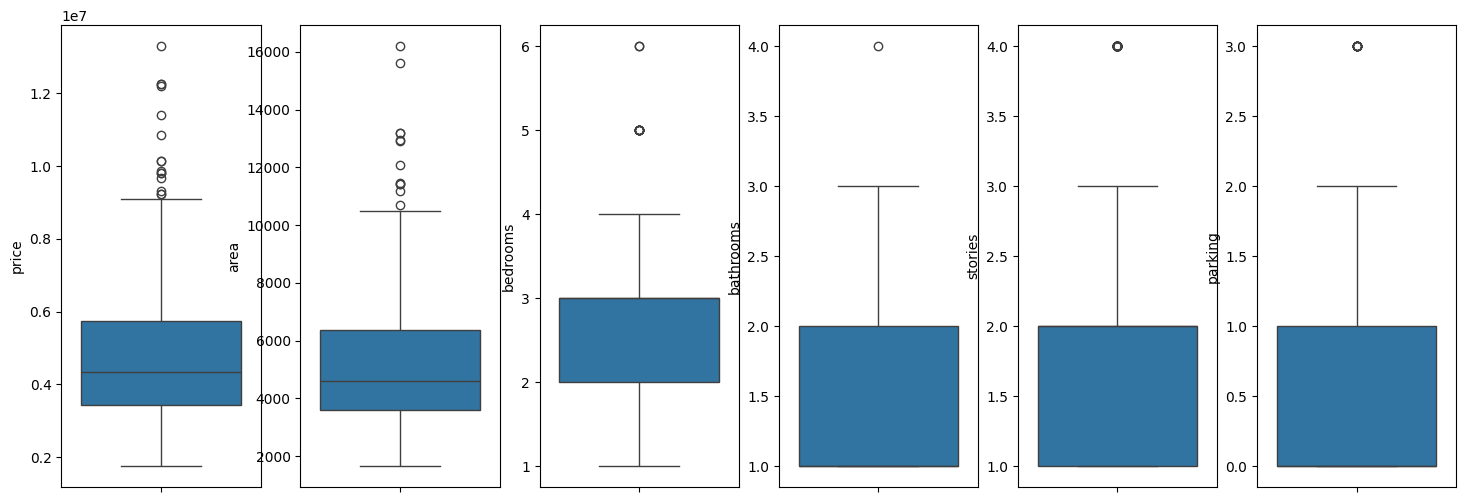

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
fix,axs = plt.subplots(1,6,figsize=(18,6))
sns.boxplot(df['price'],ax=axs[0])
sns.boxplot(df['area'],ax=axs[1])
sns.boxplot(df['bedrooms'],ax=axs[2])
sns.boxplot(df['bathrooms'],ax=axs[3])
sns.boxplot(df['stories'],ax=axs[4])
sns.boxplot(df['parking'],ax=axs[5])

In [58]:
print(df['price'].skew())
print(df['area'].skew())
print(df['bedrooms'].skew())
print(df['bathrooms'].skew())
print(df['stories'].skew())
print(df['parking'].skew())


1.2122388370279802
1.321188343153483
0.49568394074553473
1.5892635781317528
1.0820882904085742
0.8420623343734072


In [59]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [60]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [61]:
X = df.drop('price',axis=1)
y = df['price']

In [62]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

In [64]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
y_pred = rf.predict(X_test_scaled)

In [66]:
print("R2 Score :",r2_score(y_test,y_pred))
print("MAE :",mean_absolute_error(y_test,y_pred))
print("MSE :",mean_squared_error(y_test,y_pred))

R2 Score : 0.613089552175642
MAE : 1024146.5374617738
MSE : 1955666037578.7202


In [67]:
joblib.dump(rf,'house_price_model.joblib')
joblib.dump(sc,'scaler.joblib')
joblib.dump(X.columns.tolist(),'features.joblib')

['features.joblib']

In [68]:
sample = X_test.iloc[[0]]   # double [] keeps dataframe

sample_scaled = sc.transform(sample)

prediction = rf.predict(sample_scaled)

print("Predicted Price :",prediction[0])

Predicted Price : 5276880.0
